In [1]:
import torch
import numpy as np

import os

from sklearn.decomposition import PCA
#import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
device

device(type='cpu')

In [3]:
output_path = '/data/scratch/hmz574/clipped_database/encoded/'
processed_files = os.listdir(output_path)

In [4]:
pcs = False

In [5]:
pooled_features = []
pooled_names = []
if pcs:
    for file_name in processed_files:
        pooled_names.append(file_name)
        data = torch.load(output_path+file_name)
        data = data.mean(0)
        pooled_features.append(data.detach().numpy())


In [6]:
if pcs:
    pooled_array = np.array(pooled_features)
    pca = PCA(n_components=8)
    pca_features = pca.fit_transform(pooled_array)

In [7]:
pca_features = []
pca_names = []
for file_name in processed_files:
    pooled_names.append(file_name)
    data = torch.load(output_path+file_name, weights_only=True)
    if data.shape[0] == 30:
        pca_names.append(file_name)
        if pcs:
            data = pca.transform(data.detach().numpy())
        else: data = data.detach().numpy()
        pca_features.append(data)

In [8]:
classes = []
for name in pca_names:
    classes.append(name.split('_')[1])
    
batches = []
for name in pca_names:
    batches.append(name.split('_')[0])
    

In [9]:
pca_features = np.array(pca_features)
pca_features.shape

(1625, 30, 384)

In [10]:
import torch
import torch.nn as nn
from torch.autograd import Variable
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

In [11]:
from transformers import DistilBertConfig, DistilBertForSequenceClassification, DistilBertModel
dim = pca_features.shape[2]
configuration = DistilBertConfig(dim=dim,n_heads = 8,num_labels=9, n_layers=4)


In [12]:
configuration

DistilBertConfig {
  "activation": "gelu",
  "attention_dropout": 0.1,
  "dim": 384,
  "dropout": 0.1,
  "hidden_dim": 3072,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3",
    "4": "LABEL_4",
    "5": "LABEL_5",
    "6": "LABEL_6",
    "7": "LABEL_7",
    "8": "LABEL_8"
  },
  "initializer_range": 0.02,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2,
    "LABEL_3": 3,
    "LABEL_4": 4,
    "LABEL_5": 5,
    "LABEL_6": 6,
    "LABEL_7": 7,
    "LABEL_8": 8
  },
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 8,
  "n_layers": 4,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "transformers_version": "4.52.4",
  "vocab_size": 30522
}

In [13]:
model = DistilBertModel(configuration).to(device)

In [14]:
model

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 384, padding_idx=0)
    (position_embeddings): Embedding(512, 384)
    (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-3): 4 x TransformerBlock(
        (attention): DistilBertSdpaAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=384, out_features=384, bias=True)
          (k_lin): Linear(in_features=384, out_features=384, bias=True)
          (v_lin): Linear(in_features=384, out_features=384, bias=True)
          (out_lin): Linear(in_features=384, out_features=384, bias=True)
        )
        (sa_layer_norm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=384, out_features=3072, bias=True)
          (lin2): L

In [15]:
class_to_int = {
    'groom': 0,
    'rest': 1,
    'eat': 2,
    'hang': 3,
    'rear': 4,
    'drink': 5,
    'head': 6,
    'groomback': 0,
    'walk': 7,
}

labels = [class_to_int[x] for x in classes]
labels = torch.tensor(labels, dtype=torch.int64)

In [16]:
mask = np.ones(pca_features.shape)
mask[:,15:20,:] = 0.0
outputs = pca_features * mask

In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(
    torch.Tensor(pca_features), torch.Tensor(outputs), test_size=0.25, random_state=42)

In [18]:
Y_train.shape

torch.Size([1218, 30, 384])

In [19]:
# batch_size, epoch and iteration
batch_size = 50
n_iters = 25000
num_epochs = n_iters / (len(X_train) / batch_size)
num_epochs = int(num_epochs)
print(num_epochs)

# Pytorch train and test sets
train = TensorDataset(X_train, Y_train)
test = TensorDataset(X_test,Y_test)

# data loader
train_loader = DataLoader(train, batch_size = batch_size, shuffle = True)
test_loader = DataLoader(test, batch_size = batch_size, shuffle = True)

1026


In [20]:
error = nn.MSELoss()
# SGD Optimizer
learning_rate = 0.05
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [21]:
seq_dim = 30  
loss_list = []
iteration_list = []
accuracy_list = []
count = 0

In [ ]:

for epoch in range(num_epochs):
    for i, (train, targets) in enumerate(train_loader):

            
        # Clear gradients
        optimizer.zero_grad()
        model.train()
        
        # Forward propagation
        outputs = model(inputs_embeds = train.to(device))
        
        # Calculate softmax and ross entropy loss
        loss = error(outputs.last_hidden_state, targets.to(device))
        
        # Calculating gradients
        loss.backward()
        
        # Update parameters
        optimizer.step()
        
        count += 1
        
        if count % 100 == 0:
            test_loss = 0
            iterations = 0
            # Iterate through test dataset
            with torch.no_grad():
                for (test, test_targets) in test_loader:
                    model.eval()
                    # Forward propagation
                    outputs = model(inputs_embeds = test.to(device))
                    loss = error(outputs.last_hidden_state, test_targets.to(device))
                    test_loss += loss.data
                    iterations += 1
                    

                test_loss = test_loss / iterations
                # store loss and iteration
                #accuracy = correct*100/total
                loss_list.append(loss.data)
                iteration_list.append(count)
                accuracy_list.append(test_loss)
                
                # Print Loss
                print('Iteration: {}  Loss: {}  test loss: {} '.format(count, loss.data, test_loss))
                #print('Iteration: {}  Loss: {}  '.format(count, loss.data))

Iteration: 300  Loss: 1.3365626335144043  Accuracy: 1.3389040231704712 %
Iteration: 400  Loss: 1.2531707286834717  Accuracy: 1.2655543088912964 %
Iteration: 500  Loss: 1.2040811777114868  Accuracy: 1.206520676612854 %
Iteration: 600  Loss: 1.1651806831359863  Accuracy: 1.156808614730835 %
Iteration: 700  Loss: 1.1046183109283447  Accuracy: 1.1120867729187012 %
Iteration: 800  Loss: 1.0579233169555664  Accuracy: 1.0739233493804932 %
Iteration: 900  Loss: 1.0748721361160278  Accuracy: 1.046826958656311 %
Iteration: 1000  Loss: 0.980239748954773  Accuracy: 1.0130270719528198 %
Iteration: 1100  Loss: 1.0041407346725464  Accuracy: 0.9935493469238281 %
Iteration: 1200  Loss: 0.9448180198669434  Accuracy: 0.9693698883056641 %
Iteration: 1300  Loss: 0.9625619053840637  Accuracy: 0.9543606638908386 %
Iteration: 1400  Loss: 0.9255875945091248  Accuracy: 0.936482310295105 %
Iteration: 1500  Loss: 0.8969003558158875  Accuracy: 0.92106032371521 %
Iteration: 1600  Loss: 0.9131078124046326  Accuracy:

In [51]:
torch.save(model, '2layer_model.pt')

In [27]:
device

device(type='cpu')

In [28]:
import matplotlib.pyplot as plt

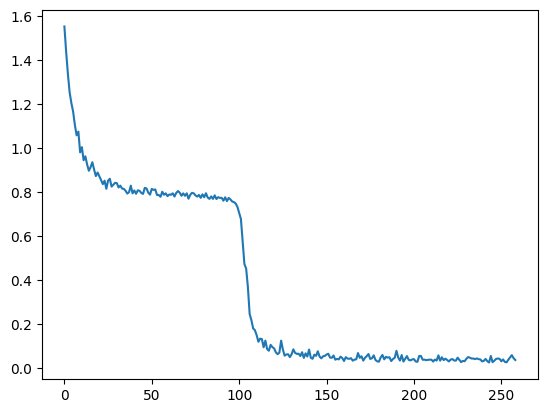

In [29]:
plt.plot(np.array([x.to('cpu') for x in loss_list]))

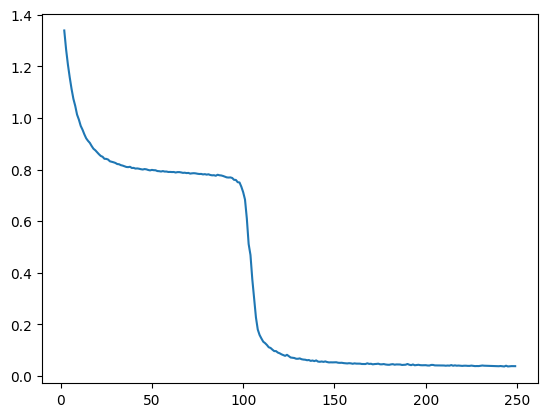

In [30]:
plt.plot(np.array([x.to('cpu') for x in accuracy_list])[:250])

In [27]:
np.array([x.to('cpu') for x in accuracy_list])[:250].max()

np.float32(98.7715)

In [ ]:
learning_rate = 0.0002
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [58]:
pca_features

array([[[-2.482023  , -1.0552812 , -3.5228965 , ..., -2.8199015 ,
         -2.2727907 , -2.3213043 ],
        [-1.980462  , -0.84129065, -4.2270403 , ..., -3.015241  ,
         -2.1831932 , -2.3765132 ],
        [-2.378011  , -0.96464205, -4.2094536 , ..., -3.2771575 ,
         -2.594848  , -1.8093677 ],
        ...,
        [-1.1329852 , -0.8408588 , -4.8835645 , ..., -3.145288  ,
         -1.9570509 , -2.7310514 ],
        [-1.0344384 , -0.87440425, -5.0236955 , ..., -2.9266531 ,
         -2.0122342 , -2.3204653 ],
        [-0.48709655, -1.0913818 , -4.767514  , ..., -3.4388077 ,
         -2.511568  , -2.5597754 ]],

       [[-3.1769886 , -1.098745  , -3.4409595 , ..., -4.115143  ,
         -1.4084585 , -1.7835574 ],
        [-3.2275567 , -1.0070461 , -3.4393325 , ..., -3.5798123 ,
         -2.0739872 , -1.6613557 ],
        [-3.2382188 , -1.2000183 , -3.60173   , ..., -3.7018583 ,
         -1.9448279 , -1.9179624 ],
        ...,
        [-3.8444548 , -1.0758905 , -3.2775578 , ..., -

In [59]:
a = model(inputs_embeds = torch.tensor(pca_features))
out = a.last_hidden_state.mean(1)

In [53]:
import umap
from sklearn.preprocessing import StandardScaler
import seaborn as sns

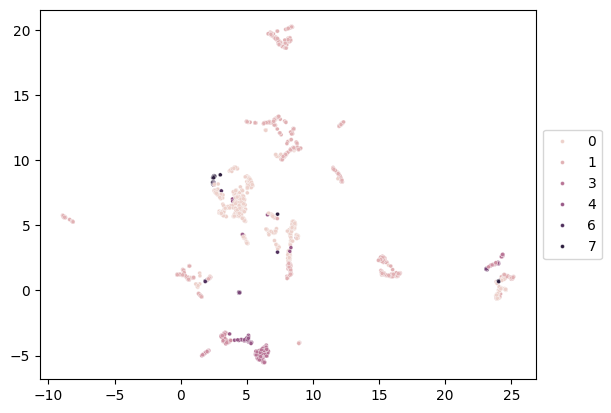

In [62]:
reducer = umap.UMAP()

scaled_features = StandardScaler().fit_transform(out.detach().numpy())
embedding = reducer.fit_transform(scaled_features)
embedding.shape

ax = sns.scatterplot(x = embedding[:,0],y = embedding[:,1], s=8,hue=labels)

ax.legend(loc = 'center left', bbox_to_anchor = (1, 0.5), ncol = 1)

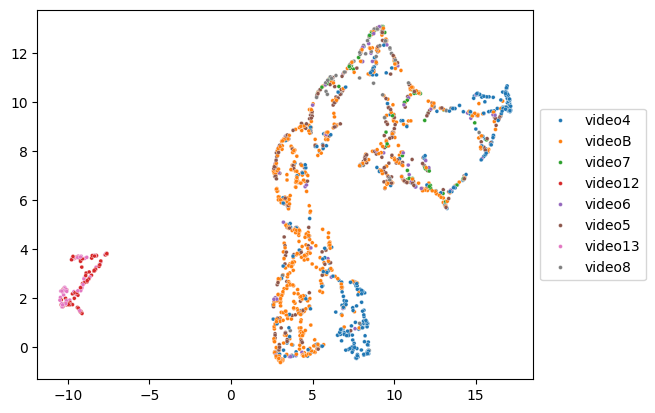

In [56]:
ax = sns.scatterplot(x = embedding[:,0],y = embedding[:,1], s=8,hue=batches)
ax.legend(loc = 'center left', bbox_to_anchor = (1, 0.5), ncol = 1)

In [88]:
pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [seaborn]m6/7 [seaborn]ib]
Note: you may need to restart the kernel to use updated packages.
